# S2 Inter-Rater Agreement — Free-Text Questions

Measures semantic agreement between all pairs of raters (human participants + models)
on free-text VQA answers using SBERT cosine similarity.

**Three comparisons (all free-text, inst_blind):**
- **HH** Human × Human — inter-participant agreement
- **MM** Model × Model — inter-model agreement
- **HM** Human × Model — cross-group agreement

**Yes/No questions are handled separately in `10b_align_agreement_yesno.ipynb`.**

In [26]:
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, spearmanr 

BASE = Path('/home/david/Desktop/yuna/HPA')
sys.path.insert(0, str(BASE / 'analysis'))

from utils.constants import VARIANT_ORDER, VARIANT_LABELS, VARIANT_COLORS

In [27]:
# ── Load human data ───────────────────────────────────────────────────────────
from utils.load_session import load_human_data, check_translation_coverage

participants, common_qids, df, mapper = load_human_data(BASE, min_answers=348)
check_translation_coverage(df, BASE / 'analysis/utils/kr_answer_map.json')

Qualifying participants (>= 348 answers): 24
  0X4B4L3T  answers=402  qids=134
  8HLCRUY1  answers=348  qids=116
  BEK0Y4W3  answers=402  qids=134
  BTTWUQG4  answers=402  qids=134
  DPCN9S37  answers=348  qids=116
  DYAN3RF8  answers=402  qids=134
  FLWP3ZF7  answers=348  qids=116
  FXDCPFHM  answers=402  qids=134
  HB857QDA  answers=348  qids=116
  HGIX7HE0  answers=402  qids=134
  IV0PL083  answers=402  qids=134
  J09HHJXK  answers=348  qids=116
  J0OU3FTE  answers=372  qids=124
  JOJCF28V  answers=372  qids=124
  K8VD3TYB  answers=348  qids=116
  MPOMQQNU  answers=348  qids=116
  NVF556XP  answers=348  qids=116
  O23790AV  answers=348  qids=116
  OBRNN1JM  answers=402  qids=134
  ON7P7X1E  answers=372  qids=124
  Q4PLE2BH  answers=348  qids=116
  TRFMV4H2  answers=372  qids=124
  Y2IBXIJX  answers=372  qids=124
  ZEF2XJBX  answers=348  qids=116
Raw Korean strings      : 2080
Already translated      : 2080
Unique canonicals to translate: 0

✓ All Korean answers already mapped.
   Lo

{'total': 8136, 'translated': 8136, 'untranslated': 0, 'added': 0}

In [28]:
# ── Load answer_type annotation from s4 ──────────────────────────────────────
q_meta = json.load(open(BASE / 'experiment/s2_v4/s4_question.json'))
answer_type_map = {q['question_id']: q['answer_type'] for q in q_meta}

# Add to df
df['answer_type'] = df['question_id'].map(answer_type_map)

# Split common_qids by type
yesno_qids = {qid for qid in common_qids if answer_type_map.get(qid) == 'yesno'}
text_qids  = {qid for qid in common_qids if answer_type_map.get(qid) == 'text'}
print(f'common_qids: {len(common_qids)} total — {len(yesno_qids)} yesno, {len(text_qids)} free-text')


common_qids: 113 total — 25 yesno, 88 free-text


In [29]:
# ── Load model results ────────────────────────────────────────────────────────
from utils.load_session import load_model_results

q_ids = set(df['question_id'].tolist())
model_q_acc, MODEL_TYPE, MODELS, ALL_MODELS = load_model_results(BASE, q_ids)

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
Loaded vqa_1k_control_inst_blind for: ['Qwen3-VL-8B', 'LLaVA-1.5-7B', 'LLaVA-Mistral', 'LLaVA-Vicuna', 'InternVL-1B', 'InternVL-2B', 'InternVL-8B', 'LLaVA-1.5 (LM)', 'LLaVA-Mistral (LM)', 'LLaVA-Vicuna (LM)', 'Qwen3-8B']
  [VLM         ] Qwen3-VL-8B: 112 questions, mean C = 0.473
  [VLM         ] LLaVA-1.5-7B: 113 questions, mean C = 0.472
  [VLM         ] LLaVA-Mistral: 113 questions, mean C = 0.537
  [VLM         ] LLaVA-Vicuna: 113 questions, mean C = 0.516
  [VLM         ] InternVL-1B: 113 questions, mean C = 0.280
  [VLM         ] InternVL-2B: 113 questions, mean C = 0.437
  [VLM         ] InternVL-8B: 113 questions, mean C = 0.366
  [LM-decoder  ] LLaVA-1.5 (LM): 113 questions, mean C = 0.537
  [LM-decoder  ] LLaVA-Mistral (LM): 113 questions, mean C = 0.537
  [LM-decoder  ] LLaVA-Vicuna (LM): 113 questions, mean C = 0.445
  [Backbone LLM] Qwen3-8

In [30]:
# ── Compute inter-participant agreement split by answer type ──────────────────
# SBERT is excluded for yesno questions — only "yes"/"no" tokens, embedding
# distance is meaningless. Use exact match and jaccard only for yesno.
from utils.agreement import compute_question_agreement

agree    = {}    # full question set
agree_tx = {}    # free-text only (all 3 metrics)
agree_yn = {}    # yesno only (exact + jaccard only, NO sbert)

for var in VARIANT_ORDER:
    print(f'\n── Variant {var} ──')
    agree[var]    = compute_question_agreement(df, common_qids,
                        methods=['exact','jaccard','sbert'],
                        answer_col='answer_en', variant=var, verbose=False)
    agree_tx[var] = compute_question_agreement(df, text_qids,
                        methods=['exact','jaccard','sbert'],
                        answer_col='answer_en', variant=var, verbose=False)
    agree_yn[var] = compute_question_agreement(df, yesno_qids,
                        methods=['exact','jaccard'],   # no SBERT for yesno
                        answer_col='answer_en', variant=var, verbose=False)
    print(f'  [text  {len(text_qids):3d}q] '
          f'exact={agree_tx[var]["exact"].mean():.3f}  '
          f'jaccard={agree_tx[var]["jaccard"].mean():.3f}  '
          f'sbert={agree_tx[var]["sbert"].mean():.3f}')
    print(f'  [yesno {len(yesno_qids):3d}q] '
          f'exact={agree_yn[var]["exact"].mean():.3f}  '
          f'jaccard={agree_yn[var]["jaccard"].mean():.3f} ')



── Variant C ──
  [text   88q] exact=0.127  jaccard=0.141  sbert=0.511
  [yesno  25q] exact=0.565  jaccard=0.565 

── Variant B ──
  [text   88q] exact=0.116  jaccard=0.127  sbert=0.493
  [yesno  25q] exact=0.601  jaccard=0.601 

── Variant A ──
  [text   88q] exact=0.103  jaccard=0.110  sbert=0.477
  [yesno  25q] exact=0.552  jaccard=0.552 


/tmp/ipykernel_1896158/1751321269.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
/tmp/ipykernel_1896158/1751321269.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
/tmp/ipykernel_1896158/1751321269.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],


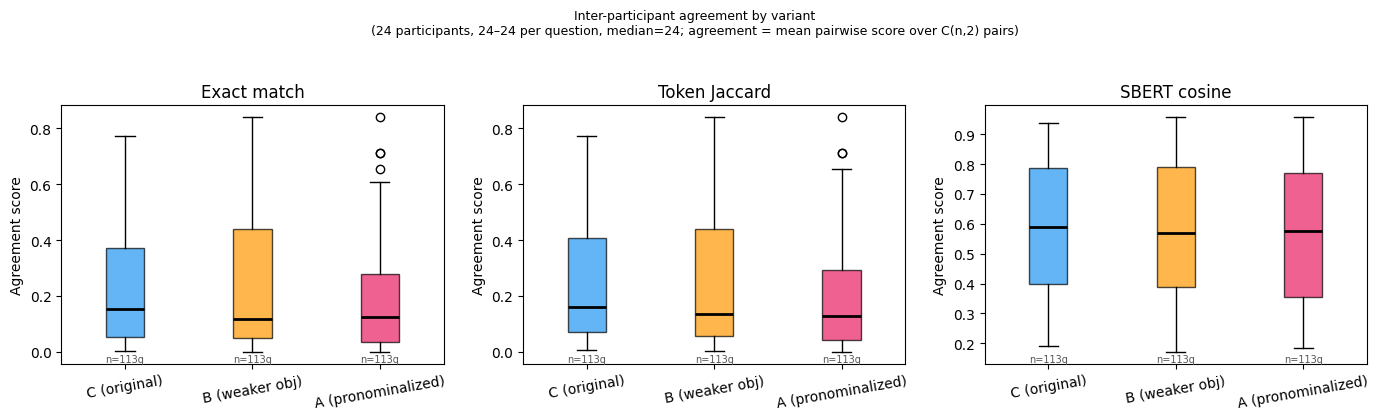

n (qids)   Mean  Median    Std    Q25    Q75
Variant Metric                                                     
C       Exact match         113  0.224   0.152  0.208  0.054  0.373
        Token Jaccard       113  0.235   0.159  0.205  0.072  0.406
        SBERT cosine        113  0.594   0.590  0.215  0.399  0.787
B       Exact match         113  0.224   0.116  0.234  0.051  0.438
        Token Jaccard       113  0.231   0.136  0.230  0.058  0.438
        SBERT cosine        113  0.581   0.569  0.226  0.387  0.790
A       Exact match         113  0.202   0.123  0.211  0.036  0.279
        Token Jaccard       113  0.207   0.127  0.208  0.041  0.292
        SBERT cosine        113  0.566   0.576  0.230  0.354  0.772

In [31]:
# ── Agreement by variant — box plots ─────────────────────────────────────────
# n per question = number of participants answering that question in variant C
# Agreement score = mean pairwise [metric] over all C(n,2) pairs of participants
# Box shows distribution across all common questions (text+yesno combined)

per_q_n = df[df['variant'] == 'C'].groupby('question_id')['answer_en'].count()
n_min, n_max, n_med = int(per_q_n.min()), int(per_q_n.max()), int(per_q_n.median())

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
methods = [('exact', 'Exact match'), ('jaccard', 'Token Jaccard'), ('sbert', 'SBERT cosine')]
colors  = {'C': '#2196F3', 'B': '#FF9800', 'A': '#E91E63'}

for ax, (meth, title) in zip(axes, methods):
    data = [agree[var][meth].dropna().values for var in VARIANT_ORDER]
    ns   = [len(d) for d in data]
    bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
                    patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, var in zip(bp['boxes'], VARIANT_ORDER):
        patch.set_facecolor(colors[var])
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel('Agreement score')
    ax.tick_params(axis='x', rotation=10)
    for i, (var, n_q) in enumerate(zip(VARIANT_ORDER, ns), 1):
        ax.text(i, ax.get_ylim()[0], f'n={n_q}q', ha='center', va='bottom',
                fontsize=7, color='#555')

n_participants = df['participant'].nunique()
plt.suptitle(
    f'Inter-participant agreement by variant\n'
    f'({n_participants} participants, {n_min}–{n_max} per question, median={n_med}; '
    f'agreement = mean pairwise score over C(n,2) pairs)',
    y=1.04, fontsize=9
)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for var in VARIANT_ORDER:
    for meth, meth_label in methods:
        vals = agree[var][meth].dropna()
        rows.append({
            'Variant':  var,
            'Metric':   meth_label,
            'n (qids)': len(vals),
            'Mean':     round(vals.mean(), 3),
            'Median':   round(vals.median(), 3),
            'Std':      round(vals.std(), 3),
            'Q25':      round(vals.quantile(0.25), 3),
            'Q75':      round(vals.quantile(0.75), 3),
        })

summary_df = pd.DataFrame(rows).set_index(['Variant', 'Metric'])
display(summary_df)

Pearson r — SBERT agreement vs human accuracy:
  Variant C: r=0.703  p=0.000  n=113
  Variant B: r=0.680  p=0.000  n=113
  Variant A: r=0.741  p=0.000  n=113


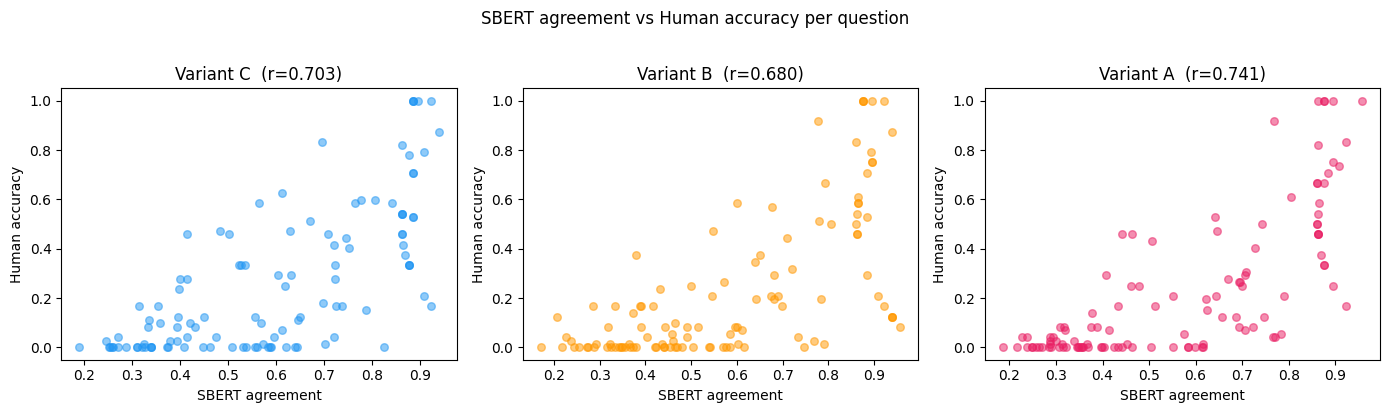

In [32]:
# ── Correlation: agreement vs human accuracy ──────────────────────────────────
# h_acc(q) = mean human accuracy per question per variant
h_acc = df.groupby(['question_id', 'variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]

print('Pearson r — SBERT agreement vs human accuracy:')
for var in VARIANT_ORDER:
    merged = agree[var][['sbert']].join(h_acc[[var]].rename(columns={var: 'acc'})).dropna()
    r, p = pearsonr(merged['sbert'], merged['acc'])
    print(f'  Variant {var}: r={r:.3f}  p={p:.3f}  n={len(merged)}')

# Scatter for variant C
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var in zip(axes, VARIANT_ORDER):
    merged = agree[var][['sbert', 'exact', 'jaccard']].join(
        h_acc[[var]].rename(columns={var: 'acc'})).dropna()
    ax.scatter(merged['sbert'], merged['acc'], alpha=0.5, color=colors[var], s=30)
    r, _ = pearsonr(merged['sbert'], merged['acc'])
    ax.set_xlabel('SBERT agreement')
    ax.set_ylabel('Human accuracy')
    ax.set_title(f'Variant {var}  (r={r:.3f})')

plt.suptitle('SBERT agreement vs Human accuracy per question', y=1.02)
plt.tight_layout()
plt.show()

Pearson r — SBERT agreement vs human accuracy:
  [All]  metric=sbert
    Variant C: r=0.703  p=0.000  n=113 questions
    Variant B: r=0.680  p=0.000  n=113 questions
    Variant A: r=0.741  p=0.000  n=113 questions
  [Yesno]  metric=exact (SBERT N/A)
    Variant C: r=0.231  p=0.267  n=25 questions
    Variant B: r=-0.432  p=0.031  n=25 questions
    Variant A: r=0.196  p=0.348  n=25 questions
  [Text]  metric=sbert
    Variant C: r=0.523  p=0.000  n=88 questions
    Variant B: r=0.573  p=0.000  n=88 questions
    Variant A: r=0.532  p=0.000  n=88 questions


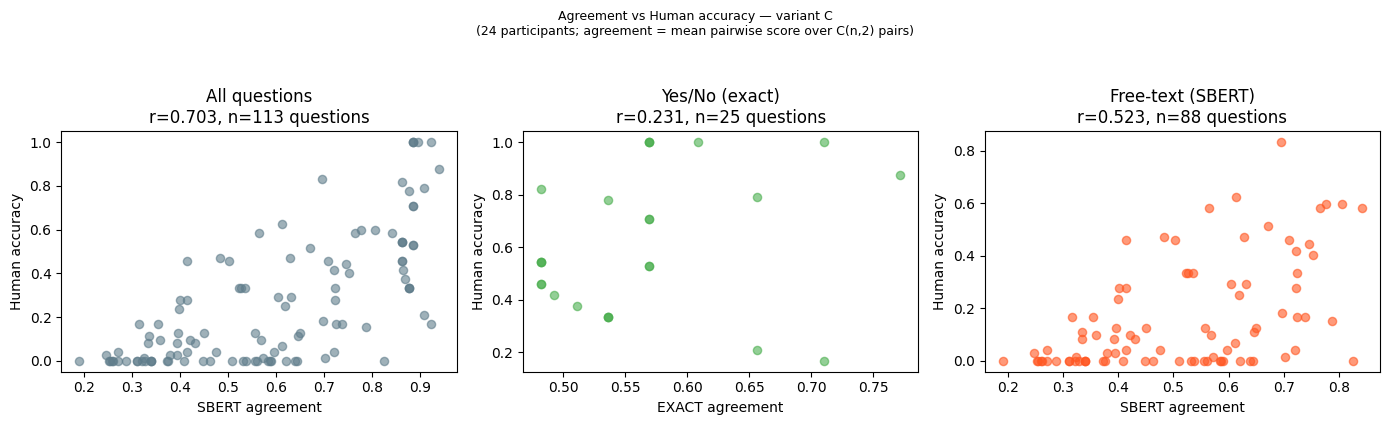

In [33]:
# ── Correlation: agreement vs human accuracy — by answer type ─────────────────
# n shown per scatter point = questions; participants per question shown in title
h_acc = df.groupby(['question_id', 'variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]

print('Pearson r — SBERT agreement vs human accuracy:')
for label, ag_dict, qids, avail_metrics in [
        ('All',   agree,    common_qids, ['sbert']),
        ('Yesno', agree_yn, yesno_qids,  ['exact']),   # no SBERT for yesno
        ('Text',  agree_tx, text_qids,   ['sbert'])]:
    print(f'  [{label}]  metric={"sbert" if "sbert" in avail_metrics else "exact (SBERT N/A)"}')
    metric = avail_metrics[0]
    for var in VARIANT_ORDER:
        merged = ag_dict[var][[metric]].join(h_acc[[var]].rename(columns={var:'acc'})).dropna()
        if len(merged) < 3:
            print(f'    Variant {var}: n={len(merged)} (too few)')
            continue
        r, p = pearsonr(merged[metric], merged['acc'])
        print(f'    Variant {var}: r={r:.3f}  p={p:.3f}  n={len(merged)} questions')

# ── Scatter variant C: All / Yesno (exact) / Text (sbert) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_cfg = [
    ('All questions',  agree,    'sbert', '#607D8B'),
    ('Yes/No (exact)', agree_yn, 'exact', '#4CAF50'),
    ('Free-text (SBERT)', agree_tx, 'sbert', '#FF5722'),
]
for ax, (label, ag_dict, metric, color) in zip(axes, plot_cfg):
    merged = ag_dict['C'][[metric]].join(h_acc[['C']].rename(columns={'C':'acc'})).dropna()
    n_q = len(merged)
    ax.scatter(merged[metric], merged['acc'], alpha=0.6, color=color, s=35)
    if n_q >= 3:
        r, _ = pearsonr(merged[metric], merged['acc'])
        ax.set_title(f'{label}\nr={r:.3f}, n={n_q} questions')
    ax.set_xlabel(f'{metric.upper()} agreement')
    ax.set_ylabel('Human accuracy')

n_participants = df['participant'].nunique()
plt.suptitle(
    f'Agreement vs Human accuracy — variant C\n'
    f'({n_participants} participants; agreement = mean pairwise score over C(n,2) pairs)',
    y=1.05, fontsize=9
)
plt.tight_layout()
plt.show()

Agreement by entity type (variant C, sorted by SBERT):
         sbert  exact  jaccard   N
ent                               
food     0.647  0.274    0.289  16
animal   0.619  0.248    0.263  17
object   0.610  0.211    0.221  27
place    0.598  0.270    0.275   5
person   0.572  0.226    0.237  26
other    0.558  0.176    0.188   9
product  0.552  0.140    0.146   5
vehicle  0.541  0.275    0.291   4
text     0.480  0.086    0.087   4


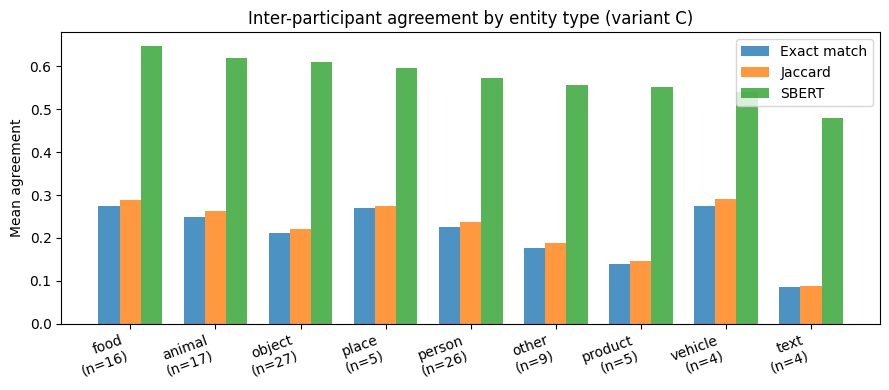

In [34]:
# ── Agreement by entity type ──────────────────────────────────────────────────
ent_map = df[['question_id', 'ent']].drop_duplicates().set_index('question_id')['ent']

ent_agree = agree['C'][['sbert', 'exact', 'jaccard']].join(ent_map).groupby('ent').mean()
ent_n     = agree['C'][['sbert']].join(ent_map).groupby('ent')['sbert'].count().rename('N')
ent_table = ent_agree.join(ent_n).sort_values('sbert', ascending=False)

print('Agreement by entity type (variant C, sorted by SBERT):')
print(ent_table.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(ent_table))
w = 0.25
ax.bar(x - w, ent_table['exact'],   w, label='Exact match', alpha=0.8)
ax.bar(x,     ent_table['jaccard'], w, label='Jaccard',     alpha=0.8)
ax.bar(x + w, ent_table['sbert'],   w, label='SBERT',       alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{e}\n(n={ent_table.loc[e,"N"]})' for e in ent_table.index],
              rotation=20, ha='right')
ax.set_ylabel('Mean agreement')
ax.set_title('Inter-participant agreement by entity type (variant C)')
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
# ── Top / bottom agreed FREE-TEXT questions (SBERT, variant C) ────────────────
# n = number of participants per question who answered in variant C
# agreement = mean pairwise SBERT cosine over all C(n,2) pairs

q_en_map = {}
for _, row in df[df['variant'] == 'C'].drop_duplicates('question_id').iterrows():
    q_en_map[row['question_id']] = row.get('question_en', str(row['question_id']))

N = 8
tx_sbert = agree_tx['C']['sbert'].dropna()

for label, ascending in [('LOWEST agreement', True), ('HIGHEST agreement', False)]:
    top = tx_sbert.sort_values(ascending=ascending).head(N)
    print(f'\n── {label} — free-text only (SBERT, variant C) ──')
    for qid, score in top.items():
        answers = df[(df.question_id == qid) & (df.variant == 'C')]['answer_en'].dropna().tolist()
        n = len(answers)
        unique  = sorted(set(answers))
        print(f'  [{score:.3f}, n={n} participants, {len(unique)} unique] {q_en_map.get(qid, qid)}')
        print(f'    answers: {unique[:6]}')


── LOWEST agreement — free-text only (SBERT, variant C) ──
  [0.190, n=24 participants, 23 unique] 1342072
    answers: ['Employment information', 'Explanation of the Eckman spiral', 'Forbidden book', 'History', 'Honeybees', 'Psychology']
  [0.247, n=24 participants, 22 unique] 229391001
    answers: ['Both are men.', 'Bought shares of Cosmo Chemical.', 'Carrying a bag.', 'Carrying luggage', 'Carrying something.', 'Riding a bicycle.']
  [0.252, n=24 participants, 23 unique] 213359003
    answers: ['Agreement', 'Bye', 'It means encouragement.', "It means he doesn't know either.", 'It means to come into the room.', 'It means to run.']
  [0.254, n=24 participants, 22 unique] 187196001
    answers: ['0', '3', 'Brand name', 'English logo', 'It says nothing.', 'Love']
  [0.259, n=24 participants, 23 unique] 169996009
    answers: ['Big Bang', 'Brooklyn', 'Ice cream shop', 'Ottre Bakery', 'Seven Eleven', 'Social Department Store']
  [0.261, n=24 participants, 22 unique] 353889001
    answers

In [36]:
# ── q_en_map: question_id → English question text (variant C) ───────────────
if 'q_en_map' not in dir():
    q_en_map = {row['question_id']: row.get('question_en', str(row['question_id']))
                for _, row in df[df['variant'] == 'C'].drop_duplicates('question_id').iterrows()}

# ── Top / bottom agreed YES/NO questions (exact match, variant C) ────────────
# For yes/no questions, SBERT is excluded (trivial token embeddings).
# Agreement = fraction of all C(n,2) participant pairs with identical answers.
# Sorted from least agreed (most split) → most agreed (strong consensus).

yn_sbert_excluded_note = '(SBERT excluded — binary token embeddings are uninformative)'

yn_exact = agree_yn['C']['exact'].dropna()
N = 8

for label, ascending in [('MOST SPLIT (lowest exact-match agreement)', True),
                          ('MOST CONSENSUS (highest exact-match agreement)', False)]:
    top = yn_exact.sort_values(ascending=ascending).head(N)
    print(f'\n── {label} — yes/no only (variant C) {yn_sbert_excluded_note} ──')
    for qid, score in top.items():
        answers = df[(df.question_id == qid) & (df.variant == 'C')]['answer_en'].dropna().tolist()
        n = len(answers)
        yn_answers = [_yn_norm(a) for a in answers]
        yes_n = yn_answers.count('yes')
        no_n  = yn_answers.count('no')
        other = n - yes_n - no_n
        other_str = f', {other} other' if other else ''
        print(f'  [exact={score:.3f}, n={n}] {q_en_map.get(qid, qid)}')
        print(f'    yes={yes_n}, no={no_n}{other_str}')


── MOST SPLIT (lowest exact-match agreement) — yes/no only (variant C) (SBERT excluded — binary token embeddings are uninformative) ──
  [exact=0.482, n=24] 568315000
    yes=11, no=13
  [exact=0.482, n=24] 212558002
    yes=11, no=13
  [exact=0.482, n=24] 269358001
    yes=11, no=13
  [exact=0.482, n=24] 298452008
    yes=13, no=11
  [exact=0.482, n=24] 446574001
    yes=11, no=13
  [exact=0.482, n=24] 375763002
    yes=13, no=11
  [exact=0.493, n=24] 119373006
    yes=14, no=10
  [exact=0.511, n=24] 105052000
    yes=15, no=9

── MOST CONSENSUS (highest exact-match agreement) — yes/no only (variant C) (SBERT excluded — binary token embeddings are uninformative) ──
  [exact=0.772, n=24] 357578013
    yes=21, no=3
  [exact=0.710, n=24] 199876000
    yes=20, no=4
  [exact=0.710, n=24] 424270008
    yes=20, no=4
  [exact=0.656, n=24] 32001021
    yes=19, no=5
  [exact=0.656, n=24] 459437005
    yes=19, no=5
  [exact=0.609, n=24] 219492002
    yes=18, no=6
  [exact=0.569, n=24] 553547000

In [37]:
# ── Question text lookups (en + kr) ─────────────────────────────────────────
q_meta_list = json.load(open(BASE / 'experiment/s2_v4/s4_question.json'))
q_en  = {q['question_id']: q['question_en'] for q in q_meta_list}
q_kr  = {q['question_id']: q['question_kr'] for q in q_meta_list}

# Variant-aware lookup (weaker_object / pronominalized JSONs have their own text)
_wb = json.load(open(BASE / 'experiment/s2_v4/s4_weaker_object.json'))
_pr = json.load(open(BASE / 'experiment/s2_v4/s4_pronominalized.json'))
q_en_var = {}  # (qid, var) → question_en
q_kr_var = {}
for entry, var in [(_wb, 'B'), (_pr, 'A')]:
    for q in entry:
        q_en_var[(q['question_id'], var)] = q.get('question_en', q_en.get(q['question_id'], ''))
        q_kr_var[(q['question_id'], var)] = q.get('question_kr', q_kr.get(q['question_id'], ''))
for qid in common_qids:
    q_en_var[(qid, 'C')] = q_en.get(qid, '')
    q_kr_var[(qid, 'C')] = q_kr.get(qid, '')

print(f"Question text loaded for {len(q_en)} questions")

Question text loaded for 134 questions


## HH / MM / HM Agreement — Free-Text Questions

In [38]:
# ── Collect individual rater answers (free-text questions only) ───────────────
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

HF_CACHE = '/home/david/Desktop/yuna/.cache/hf'
embedder  = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2',
                                 cache_folder=HF_CACHE)

CT_TO_VARIANT = {'question': 'C', 'weaker_object': 'B', 'pronominalized': 'A'}

RATER_MODELS = {
    'Qwen3-VL-8B':        ('vlm',        'pretrained',              'Qwen3-VL-8B-Instruct'),
    'LLaVA-1.5-7B':       ('vlm',        'pretrained',              'llava-1.5-7b-hf'),
    'LLaVA-Mistral':      ('vlm',        'pretrained',              'llava-v1.6-mistral-7b-hf'),
    'LLaVA-Vicuna':       ('vlm',        'pretrained',              'llava-v1.6-vicuna-7b-hf'),
    'LLaVA-1.5 (LM)':     ('lm_decoder', 'lm_decoder/pretrained',   'llava-1.5-7b-hf'),
    'LLaVA-Mistral (LM)': ('lm_decoder', 'lm_decoder/pretrained',   'llava-v1.6-mistral-7b-hf'),
    'LLaVA-Vicuna (LM)':  ('lm_decoder', 'lm_decoder/pretrained',   'llava-v1.6-vicuna-7b-hf'),
    'Qwen3-8B':           ('backbone',   'backbone/pretrained',      'Qwen3-8B'),
}

# rater_answers[rater_id][(qid, var)] = answer_text
rater_answers = {}
rater_group   = {}   # rater_id → 'human'|'vlm'|'lm_decoder'|'backbone'

# Human participants
for p in participants:
    pid = p['code']
    rater_group[pid]   = 'human'
    rater_answers[pid] = {}
    for a in p['answers']:
        qid = a['question_id']
        if qid not in text_qids: continue
        var = a.get('variant', 'C')
        ans = str(a.get('answer_en', '')).strip().lower()
        if ans:
            rater_answers[pid][(qid, var)] = ans

# Individual models
from utils.load_session import clean_answer as _clean_answer
for label, (gname, tier, mdir) in RATER_MODELS.items():
    path = BASE / 'evaluation/logits' / tier / mdir / 'vqa_1k_control_inst_blind.jsonl'
    if not path.exists():
        print(f'  MISSING: {label}'); continue
    rater_group[label]   = gname
    rater_answers[label] = {}
    for line in open(path):
        ex  = json.loads(line)
        qid = int(ex['question_id'])
        if qid not in text_qids: continue
        ga  = ex.get('generated_answers', {})
        for ct, var in CT_TO_VARIANT.items():
            ans = _clean_answer(ga.get(ct, '')).strip().lower()
            if ans:
                rater_answers[label][(qid, var)] = ans

all_raters  = list(rater_answers.keys())
human_raters = [r for r in all_raters if rater_group[r] == 'human']
model_raters = [r for r in all_raters if rater_group[r] != 'human']
print(f"Raters: {len(human_raters)} humans + {len(model_raters)} models = {len(all_raters)} total")

# ── Embed all unique answer strings once ──────────────────────────────────────
all_answers = sorted({
    ans
    for r in all_raters
    for ans in rater_answers[r].values()
})
print(f"Unique answer strings to embed: {len(all_answers)}")
emb_matrix = embedder.encode(all_answers, batch_size=256,
                              show_progress_bar=True, convert_to_numpy=True)
ans2emb = {a: emb_matrix[i] for i, a in enumerate(all_answers)}
print("Embedding done.")

Raters: 24 humans + 8 models = 32 total
Unique answer strings to embed: 444


Batches: 100%|██████████| 2/2 [00:00<00:00, 24.69it/s]

Embedding done.


In [39]:
# ── Build full pairs DataFrame (free-text, all variants) ─────────────────────
from itertools import combinations

pair_rows = []

for var in VARIANT_ORDER:
    for qid in sorted(text_qids):
        q_answers = {r: rater_answers[r].get((qid, var)) for r in all_raters}
        q_answers = {r: a for r, a in q_answers.items() if a and a in ans2emb}
        if len(q_answers) < 2: continue

        present = list(q_answers.keys())
        q_en_text = q_en_var.get((qid, var), q_en.get(qid, ''))
        q_kr_text = q_kr_var.get((qid, var), q_kr.get(qid, ''))

        for r1, r2 in combinations(present, 2):
            g1, g2 = rater_group[r1], rater_group[r2]
            # canonical pair_type: HH, MM, HM
            if g1 == 'human' and g2 == 'human':
                ptype = 'HH'
            elif g1 != 'human' and g2 != 'human':
                ptype = 'MM'
            else:
                ptype = 'HM'
                # always put human first
                if g1 != 'human':
                    r1, r2 = r2, r1
                    g1, g2 = g2, g1

            e1 = ans2emb[q_answers[r1]]
            e2 = ans2emb[q_answers[r2]]
            score = float(np.dot(e1, e2) / (np.linalg.norm(e1) * np.linalg.norm(e2)))

            pair_rows.append({
                'question_id':     qid,
                'question_en':     q_en_text,
                'question_kr':     q_kr_text,
                'variant':         var,
                'pair_type':       ptype,
                'subject_group_1': g1,
                'subject_1':       r1,
                'subject_group_2': g2,
                'subject_2':       r2,
                'answer_1':        q_answers[r1],
                'answer_2':        q_answers[r2],
                'sbert_score':     round(score, 4),
            })

pairs_df = pd.DataFrame(pair_rows)
print(f"Total pairs: {len(pairs_df):,}")
print(pairs_df.groupby('pair_type').size().rename('n_pairs'))

Total pairs: 7,378
pair_type
MM    7378
Name: n_pairs, dtype: int64


/tmp/ipykernel_1896158/677746354.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_type, labels=['HH\n(human–human)', 'MM\n(model–model)', 'HM\n(human–model)'],


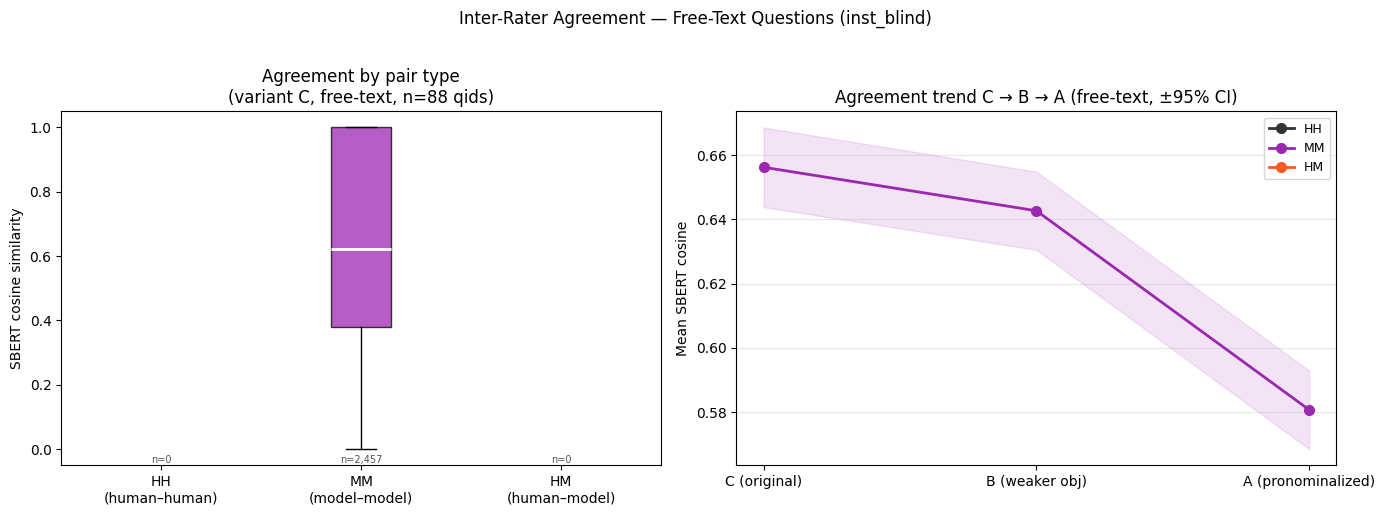

n pairs   Mean  Median    Std
Variant Pair type                               
C       HH               0    NaN     NaN    NaN
        MM            2457  0.656   0.622  0.313
        HM               0    NaN     NaN    NaN
B       HH               0    NaN     NaN    NaN
        MM            2457  0.643   0.590  0.308
        HM               0    NaN     NaN    NaN
A       HH               0    NaN     NaN    NaN
        MM            2464  0.581   0.529  0.309
        HM               0    NaN     NaN    NaN

In [40]:
# ── Three-way agreement box plot: HH / MM / HM (variant C, free-text) ─────────
from IPython.display import display

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution by pair type (variant C)
ax = axes[0]
C_df = pairs_df[pairs_df.variant == 'C']
data_by_type = [C_df[C_df.pair_type == pt]['sbert_score'].values
                for pt in ['HH', 'MM', 'HM']]
colors_bt = ['#333333', '#9C27B0', '#FF5722']
bp = ax.boxplot(data_by_type, labels=['HH\n(human–human)', 'MM\n(model–model)', 'HM\n(human–model)'],
                patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, c in zip(bp['boxes'], colors_bt):
    patch.set_facecolor(c); patch.set_alpha(0.75)
for i, (pt, d) in enumerate(zip(['HH','MM','HM'], data_by_type), 1):
    ax.text(i, ax.get_ylim()[0], f'n={len(d):,}', ha='center',
            va='bottom', fontsize=7, color='#555')
ax.set_ylabel('SBERT cosine similarity')
ax.set_title(f'Agreement by pair type\n(variant C, free-text, n={C_df["question_id"].nunique()} qids)')
ax.set_ylim(-0.05, 1.05)

# Right: per-variant trend for each pair type
ax = axes[1]
x = np.arange(len(VARIANT_ORDER))
for pt, color in zip(['HH', 'MM', 'HM'], colors_bt):
    means = [pairs_df[(pairs_df.variant == v) & (pairs_df.pair_type == pt)]['sbert_score'].mean()
             for v in VARIANT_ORDER]
    sems  = [pairs_df[(pairs_df.variant == v) & (pairs_df.pair_type == pt)]['sbert_score'].sem()
             for v in VARIANT_ORDER]
    ax.plot(x, means, 'o-', color=color, label=pt, lw=2, ms=7)
    ax.fill_between(x,
                    np.array(means) - 1.96*np.array(sems),
                    np.array(means) + 1.96*np.array(sems),
                    color=color, alpha=0.12)
ax.set_xticks(x)
ax.set_xticklabels(['C (original)', 'B (weaker obj)', 'A (pronominalized)'])
ax.set_ylabel('Mean SBERT cosine')
ax.set_title('Agreement trend C → B → A (free-text, ±95% CI)')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Inter-Rater Agreement — Free-Text Questions (inst_blind)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
tbl_rows = []
for var in VARIANT_ORDER:
    for pt in ['HH', 'MM', 'HM']:
        vals = pairs_df[(pairs_df.variant == var) & (pairs_df.pair_type == pt)]['sbert_score']
        tbl_rows.append({'Variant': var, 'Pair type': pt, 'n pairs': len(vals),
                         'Mean': round(vals.mean(), 3), 'Median': round(vals.median(), 3),
                         'Std': round(vals.std(), 3)})
display(pd.DataFrame(tbl_rows).set_index(['Variant', 'Pair type']))

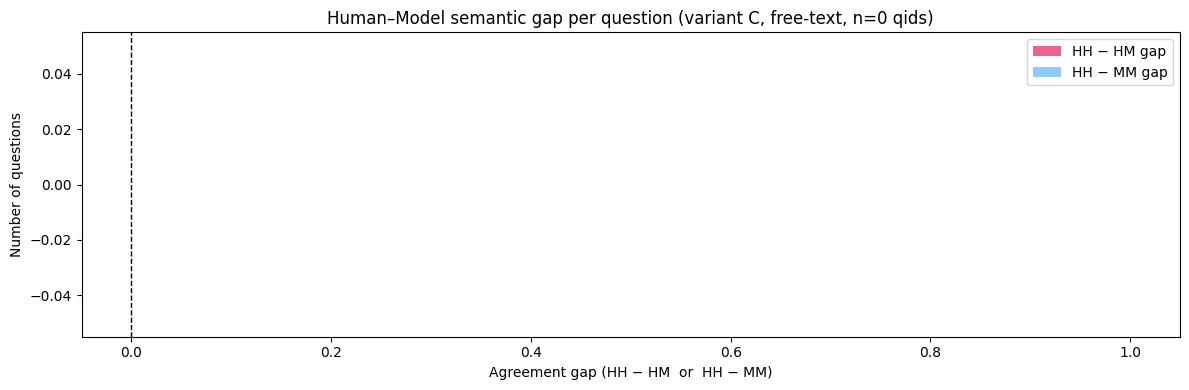

Mean HH−HM gap: nan  (positive = humans agree more with each other than with models)
Mean HH−MM gap: nan

── Top 8 questions with LARGEST human–model gap ──


,question_en,HH,MM,HM,gap_HM
question_id,,,,,



── Top 8 questions with SMALLEST human–model gap (most aligned) ──


,question_en,HH,MM,HM,gap_HM
question_id,,,,,


In [41]:
# ── Per-question gap: HH − HM (variant C, free-text) ─────────────────────────
hh_q = (pairs_df[(pairs_df.variant == 'C') & (pairs_df.pair_type == 'HH')]
        .groupby('question_id')['sbert_score'].mean().rename('HH'))
mm_q = (pairs_df[(pairs_df.variant == 'C') & (pairs_df.pair_type == 'MM')]
        .groupby('question_id')['sbert_score'].mean().rename('MM'))
hm_q = (pairs_df[(pairs_df.variant == 'C') & (pairs_df.pair_type == 'HM')]
        .groupby('question_id')['sbert_score'].mean().rename('HM'))

gap_df = pd.concat([hh_q, mm_q, hm_q], axis=1).dropna()
gap_df['gap_HM']  = gap_df['HH'] - gap_df['HM']   # positive = humans agree more with each other than with models
gap_df['gap_MM']  = gap_df['HH'] - gap_df['MM']
gap_df['question_en'] = gap_df.index.map(lambda q: q_en.get(q, ''))
gap_df = gap_df.sort_values('gap_HM', ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(gap_df['gap_HM'], bins=30, color='#E91E63', alpha=0.7, label='HH − HM gap')
ax.hist(gap_df['gap_MM'], bins=30, color='#2196F3', alpha=0.5, label='HH − MM gap')
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Agreement gap (HH − HM  or  HH − MM)')
ax.set_ylabel('Number of questions')
ax.set_title(f'Human–Model semantic gap per question (variant C, free-text, n={len(gap_df)} qids)')
ax.legend()
plt.tight_layout(); plt.show()

print(f"Mean HH−HM gap: {gap_df['gap_HM'].mean():.3f}  "
      f"(positive = humans agree more with each other than with models)")
print(f"Mean HH−MM gap: {gap_df['gap_MM'].mean():.3f}")

print("\n── Top 8 questions with LARGEST human–model gap ──")
display(gap_df[['question_en','HH','MM','HM','gap_HM']].head(8).round(3))

print("\n── Top 8 questions with SMALLEST human–model gap (most aligned) ──")
display(gap_df[['question_en','HH','MM','HM','gap_HM']].tail(8).round(3))

In [42]:
# ── Full pairwise agreement heatmap (all raters × all raters, variant C) ──────
# Mean SBERT cosine across all free-text questions, variant C
pair_mean = (pairs_df[pairs_df.variant == 'C']
             .groupby(['subject_1', 'subject_2'])['sbert_score'].mean())

rater_order = human_raters + model_raters
n = len(rater_order)
heat = pd.DataFrame(np.nan, index=rater_order, columns=rater_order)

for r1, r2 in combinations(rater_order, 2):
    val = pair_mean.get((r1, r2), pair_mean.get((r2, r1), np.nan))
    heat.loc[r1, r2] = val
    heat.loc[r2, r1] = val
np.fill_diagonal(heat.values, 1.0)

fig, ax = plt.subplots(figsize=(13, 11))
import seaborn as sns
sns.heatmap(heat, ax=ax, cmap='RdYlGn', vmin=0.3, vmax=1.0,
            annot=True, fmt='.2f', annot_kws={'size': 6},
            linewidths=0.3, linecolor='white',
            xticklabels=rater_order, yticklabels=rater_order)

# Block borders: human block vs model block
n_h = len(human_raters)
for pos in [n_h]:
    ax.axhline(pos, color='black', lw=2)
    ax.axvline(pos, color='black', lw=2)

# Block labels
ax.text(n_h / 2, -0.8, 'Human', ha='center', fontsize=10,
        fontweight='bold', transform=ax.get_xaxis_transform())
ax.text((n_h + n) / 2, -0.8, 'Models', ha='center', fontsize=10,
        fontweight='bold', transform=ax.get_xaxis_transform())

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
ax.set_title(
    f'Pairwise SBERT agreement — all raters × all raters\n'
    f'(variant C, free-text, n={gap_df.shape[0]} qids)',
    fontsize=11
)
plt.tight_layout(); plt.show()

ValueError: underlying array is read-only

In [ ]:
# ── Export full pairs table to CSV ───────────────────────────────────────────
OUT = BASE / 'analysis/session2/exports'
OUT.mkdir(exist_ok=True)
out_path = OUT / 'answer_pairs_sbert_text.csv'
pairs_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}  ({len(pairs_df):,} rows, {pairs_df.memory_usage(deep=True).sum()/1e6:.1f} MB)")

# ── Display sample: top/bottom 10 HM pairs by SBERT score ────────────────────
hm = pairs_df[(pairs_df.variant == 'C') & (pairs_df.pair_type == 'HM')].copy()

print("\n── 10 LOWEST scoring HM pairs (variant C) ──")
cols = ['question_en','subject_1','subject_2','answer_1','answer_2','sbert_score']
display(hm.nsmallest(10, 'sbert_score')[cols].reset_index(drop=True))

print("\n── 10 HIGHEST scoring HM pairs (variant C) ──")
display(hm.nlargest(10, 'sbert_score')[cols].reset_index(drop=True))